In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import numpy as np


In [25]:
car=pd.read_csv(r"D:\web project\vehicle-price-predictor\data\cleaned_toyota_dataset.csv")
car.head()

,Price,Make,Model,Year,Mileage,Transmission,Fuel type,Engine capacity,Condition,vehicle_age
0,13500000,Toyota,Raize,2025,20.0,Automatic,Petrol,1000.0,Reconditioned,1
1,5795000,Toyota,Corolla,2001,210000.0,Automatic,Petrol,1500.0,Used,25
2,29500000,Toyota,Hilux,2026,0.0,Tiptronic,Diesel,2800.0,Brand New,0
3,40500000,Toyota,Harrier,2025,4500.0,Tiptronic,Hybrid,2500.0,Used,1
4,68990000,Toyota,Land Cruiser Prado,2024,1000.0,Automatic,Petrol,2700.0,Brand New,2


Text(0.5, 1.0, 'Engine capacity vs Price')

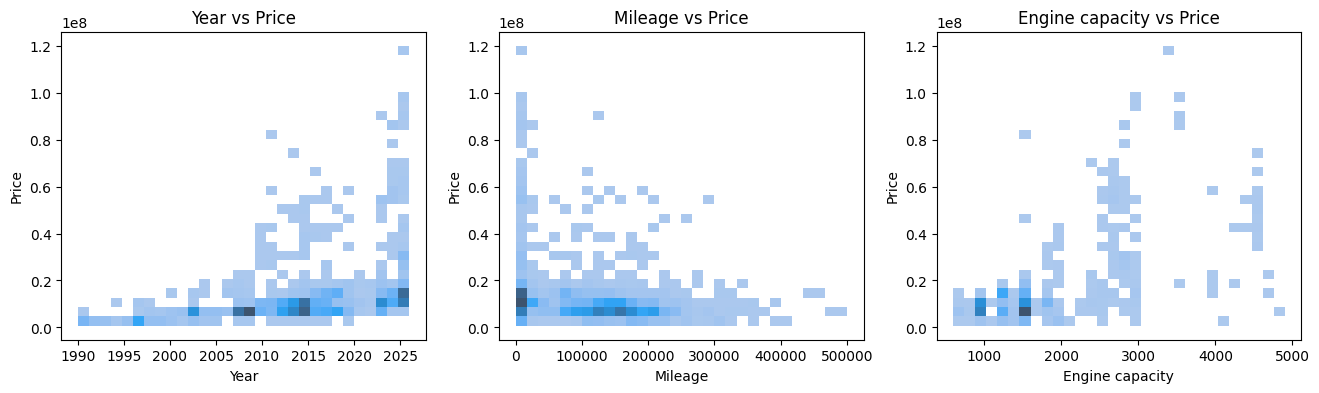

In [26]:
plt.figure(figsize=(16, 4))

plt.subplot(1, 3, 1)
sns.histplot(x=car["Year"], y=car["Price"],bins=30)
plt.title("Year vs Price")

plt.subplot(1, 3, 2)
sns.histplot(x=car["Mileage"], y=car["Price"], bins=30) 
plt.title("Mileage vs Price")

plt.subplot(1, 3, 3)
sns.histplot(x=car["Engine capacity"], y=car["Price"], bins=30)
plt.title("Engine capacity vs Price")



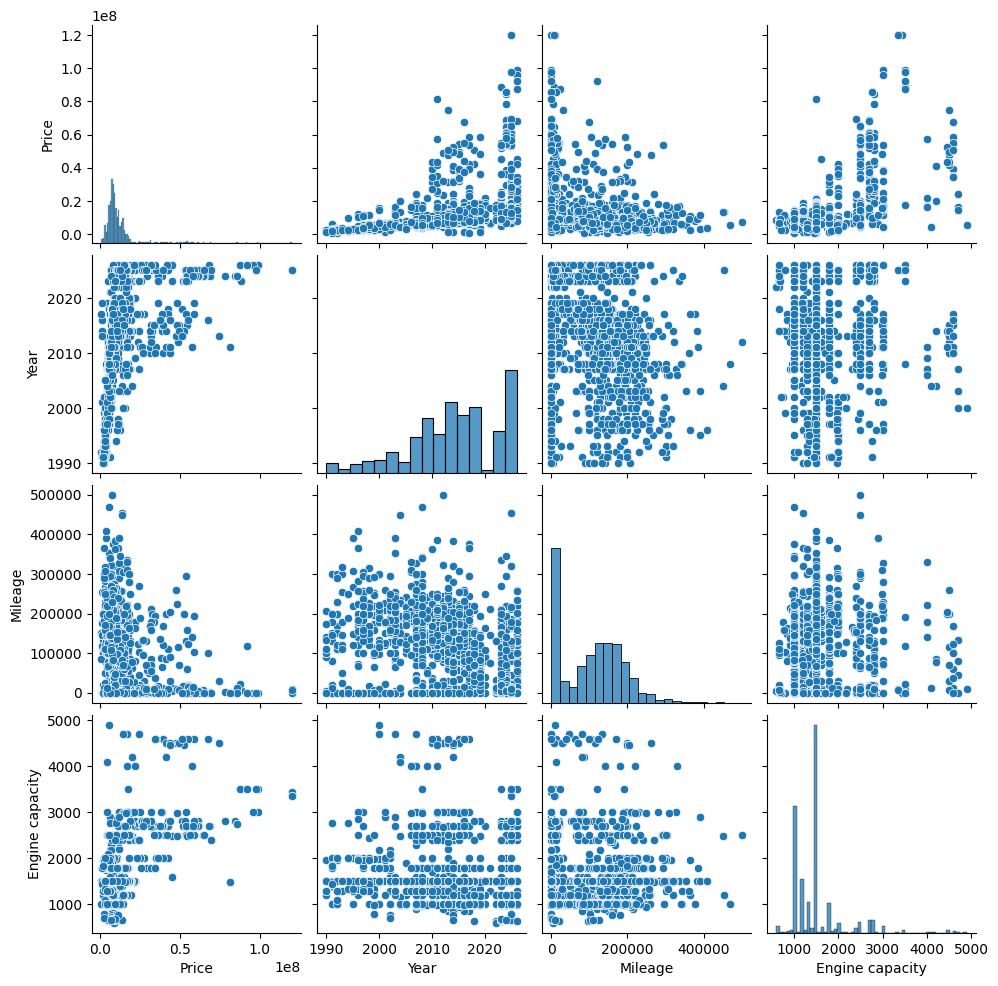

In [27]:
sns.pairplot(car[["Price", "Year", "Mileage", "Engine capacity"]])
plt.show()

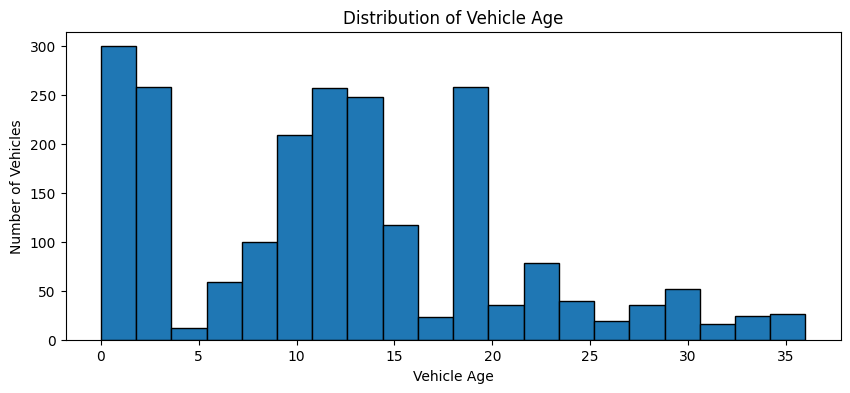

In [28]:
plt.figure(figsize=(10, 4))
plt.hist(car["vehicle_age"], bins=20, edgecolor='black')

plt.xlabel("Vehicle Age")
plt.ylabel("Number of Vehicles")
plt.title("Distribution of Vehicle Age")
plt.show()

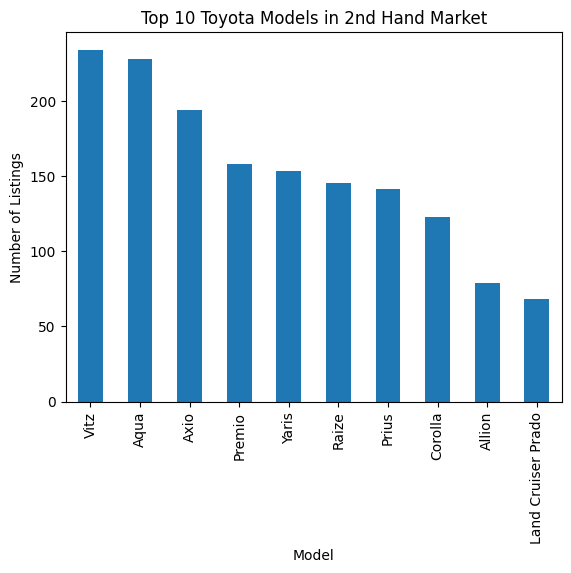

In [29]:

top_models = car["Model"].value_counts().head(10)
top_models.plot.bar()

plt.title("Top 10 Toyota Models in 2nd Hand Market")
plt.xlabel("Model")
plt.ylabel("Number of Listings")
plt.show()

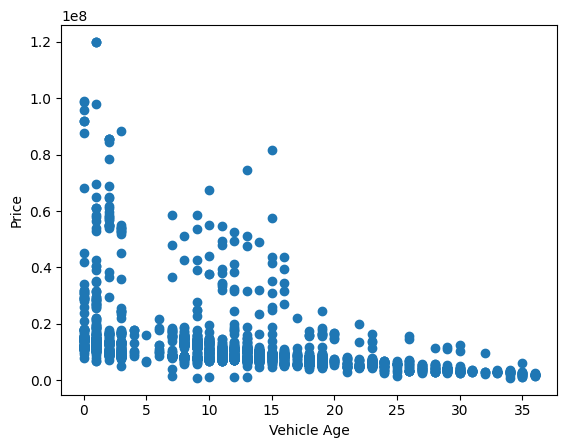

In [30]:
plt.scatter(car["vehicle_age"], car["Price"])
plt.xlabel("Vehicle Age")
plt.ylabel("Price")
plt.show()

<Axes: ylabel='count'>

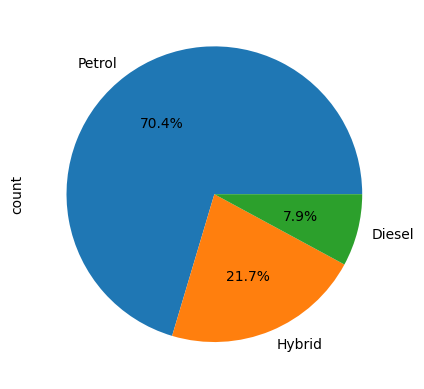

In [31]:
car["Fuel type"].value_counts().plot(kind="pie", autopct="%1.1f%%")

In [34]:
log_price = np.log(car["Price"])
car["log_price"]= log_price
car.head()

,Price,Make,Model,Year,Mileage,Transmission,Fuel type,Engine capacity,Condition,vehicle_age,log_price
0,13500000,Toyota,Raize,2025,20.0,Automatic,Petrol,1000.0,Reconditioned,1,16.418200
1,5795000,Toyota,Corolla,2001,210000.0,Automatic,Petrol,1500.0,Used,25,15.572506
2,29500000,Toyota,Hilux,2026,0.0,Tiptronic,Diesel,2800.0,Brand New,0,17.199901
3,40500000,Toyota,Harrier,2025,4500.0,Tiptronic,Hybrid,2500.0,Used,1,17.516813
4,68990000,Toyota,Land Cruiser Prado,2024,1000.0,Automatic,Petrol,2700.0,Brand New,2,18.049472


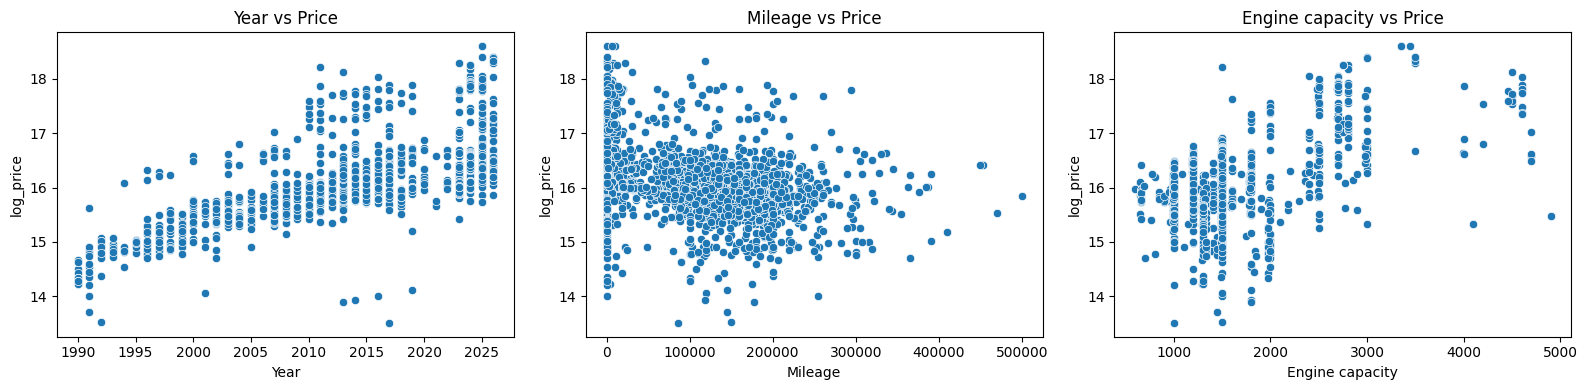

In [38]:

plt.figure(figsize=(16, 4))


plt.subplot(1, 3, 1)
sns.scatterplot(x=car["Year"], y=car["log_price"])
plt.title("Year vs Price")


plt.subplot(1, 3, 2)
sns.scatterplot(x=car["Mileage"], y=car["log_price"]) 
plt.title("Mileage vs Price")

plt.subplot(1, 3, 3)
sns.scatterplot(x=car["Engine capacity"], y=car["log_price"])
plt.title("Engine capacity vs Price")

plt.tight_layout() # Keeps the plots from crowding each other
plt.show()

In [40]:
print(car.head())

      Price    Make               Model  Year   Mileage Transmission  \
0  13500000  Toyota               Raize  2025      20.0    Automatic   
1   5795000  Toyota             Corolla  2001  210000.0    Automatic   
2  29500000  Toyota               Hilux  2026       0.0    Tiptronic   
3  40500000  Toyota             Harrier  2025    4500.0    Tiptronic   
4  68990000  Toyota  Land Cruiser Prado  2024    1000.0    Automatic   

  Fuel type  Engine capacity      Condition  vehicle_age  log_price  
0    Petrol           1000.0  Reconditioned            1  16.418200  
1    Petrol           1500.0           Used           25  15.572506  
2    Diesel           2800.0      Brand New            0  17.199901  
3    Hybrid           2500.0           Used            1  17.516813  
4    Petrol           2700.0      Brand New            2  18.049472  


Apply One-Hot Encoding

In [41]:
categorical_cols = [
    "Model",
    "Fuel type",
    "Transmission",
    "Condition"
]

car_encoded = pd.get_dummies(
    car,
    columns=categorical_cols,
    drop_first=True
)

In [42]:
car_encoded.head()

,Price,Make,Year,Mileage,Engine capacity,vehicle_age,log_price,Model_AE100,Model_AQUA URBAN,Model_AXIO(DAA-NKE165),...,Transmission_Other,Transmission_Other transmission,Transmission_Tiptronic,Condition_Brand New,Condition_Import,Condition_Reconditioned,Condition_Registered,Condition_Registered (Used),Condition_Unregistered (Recondition),Condition_Used
0,13500000,Toyota,2025,20.0,1000.0,1,16.418200,False,False,False,...,False,False,False,False,False,True,False,False,False,False
1,5795000,Toyota,2001,210000.0,1500.0,25,15.572506,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,29500000,Toyota,2026,0.0,2800.0,0,17.199901,False,False,False,...,False,False,True,True,False,False,False,False,False,False
3,40500000,Toyota,2025,4500.0,2500.0,1,17.516813,False,False,False,...,False,False,True,False,False,False,False,False,False,True
4,68990000,Toyota,2024,1000.0,2700.0,2,18.049472,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [43]:
car_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2168 entries, 0 to 2167
Columns: 150 entries, Price to Condition_Used
dtypes: bool(143), float64(3), int64(3), object(1)
memory usage: 421.4+ KB


In [44]:
car.shape

(2168, 11)

In [47]:
car.groupby("Model")["Price"].mean().sort_values(ascending=False)

Model
Land Cruiser Sahara    5.924464e+07
Alphard                5.571111e+07
Land Cruiser           5.460556e+07
Land Cruiser Prado     4.736044e+07
Vellfire               4.725000e+07
                           ...     
Corolla DX             2.450000e+06
Corona                 2.100000e+06
Vista Turbo            2.050000e+06
DX Wagon               1.750000e+06
EE 90 Special          1.595000e+06
Name: Price, Length: 131, dtype: float64

In [49]:
car[["Price","Mileage","Year","Engine capacity"]].corr()

,Price,Mileage,Year,Engine capacity
Price,1.000000,-0.282364,0.410371,0.608894
Mileage,-0.282364,1.000000,-0.483603,0.033172
Year,0.410371,-0.483603,1.000000,-0.110195
Engine capacity,0.608894,0.033172,-0.110195,1.000000
